In [3]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def graph_of_data(df):
    #merge these columns, will be labels of the nodes
    df["Name"] = df["Candidate surname"].astype("str") +" " + df["Candidate First Name"].astype("str")
    #create the DiGraph
    G = nx.DiGraph()
    count_lst = list(df["Count Number"].unique())
    count_lst.remove(1)
    #DEBUG: print(count_lst)
    #filter by count
    for count in count_lst:
        filtered_df1 = df[df["Count Number"]==count]
        #DEBUG: filtered_df1
        #--get names of those whose votes are transferred
        src_cands = filtered_df1[filtered_df1["ln(Transfers)"]<0]
        #DEBUG: src_cands
        #--get names of those who receive these transfers
        to_cands =filtered_df1[filtered_df1["ln(Transfers)"]>0]
        #DEBUG: to_cands
        src_names = list(src_cands["Name"].values)
        #DEBUG: src_names
        to_names = list(to_cands["Name"].values)
        #DEBUG: to_names
        #--get number of transfers
        wgts = list(to_cands["ln(Transfers)"].values)
        #DEBUG: wgts
        
        #--Create a weighted edge between each source candidate and each target candidate
        
        for i in range(len(src_names)):
            edge_list = []
            for j in range(len(to_names)):
                edge = (src_names[i],to_names[j],wgts[j])
                print(edge)
                edge_list.append(edge)
            G.add_weighted_edges_from(edge_list)
    return G
    

In [18]:
### make_networkx_from_csv.py
# DM and JMcG 30 Oct 2025
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def graph_of_data(df):
    #--Merge these columns, will be labels of the nodes
    df["Name"] = df["Candidate surname"].astype("str") +" " + df["Candidate First Name"].astype("str")
    #--Create the DiGraph
    G = nx.DiGraph()
    count_lst = list(df["Count Number"].unique())
    count_lst.remove(1)
    
    #--Filter by count
    for count in count_lst:
        filtered_df1 = df[df["Count Number"]==count]
        #--get names of those whose votes are transferred
        src_cands = filtered_df1[filtered_df1["Transfers"]<0]
        #--get names of those who receive these transfers
        to_cands =filtered_df1[filtered_df1["Transfers"]>0]
        src_names = list(src_cands["Name"].values)
        to_names = list(to_cands["Name"].values)
        
        #--get number of transfers
        
        wgts = []
        src_wgts = list(src_cands["Transfers"].values)
        to_wgts = list(to_cands["Transfers"].values)
        
        total=0
        for src_wgt in src_wgts:
            total+=src_wgt
        total=np.abs(total)
        
        for i in range(len(to_wgts)):
            
            quotient = to_wgts[i] / total
            #ln_quotient = np.log(quotient)
            normalised_wgt = quotient*np.log(to_wgts[i])
            wgts.append(round(normalised_wgt,2))
            
        for i in range(len(src_names)):
            for j in range(len(to_names)):
                G.add_edge(src_names[i],to_names[j],weight=wgts[j])
    return G

In [19]:
G1 = graph_of_data(donegal_df)

In [20]:
for i in G1.edges("Mc Guinness Arthur Desmond",data=True):
    print(i)

('Mc Guinness Arthur Desmond', 'Casey Peter', {'weight': 1.01})
('Mc Guinness Arthur Desmond', 'Gallagher Pat The Cope', {'weight': 0.16})
('Mc Guinness Arthur Desmond', 'Harley Martin M.', {'weight': 0.08})
('Mc Guinness Arthur Desmond', 'McConalogue Charlie', {'weight': 0.24})
('Mc Guinness Arthur Desmond', 'McHugh Joe', {'weight': 0.16})
('Mc Guinness Arthur Desmond', "O'Donnell John", {'weight': 0.56})
('Mc Guinness Arthur Desmond', 'Pringle Thomas', {'weight': 0.49})
('Mc Guinness Arthur Desmond', 'Sweeney Mary T.', {'weight': 1.27})
('Mc Guinness Arthur Desmond', 'White Michael', {'weight': 0.09})


In [22]:
for i in G1.edges("Doherty Pearse",data=True):
    print(i)

('Doherty Pearse', 'Casey Peter', {'weight': 0.53})
('Doherty Pearse', 'Gallagher Pat The Cope', {'weight': 1.04})
('Doherty Pearse', 'Harley Martin M.', {'weight': 0.32})
('Doherty Pearse', 'Mc Guinness Arthur Desmond', {'weight': 0.02})
('Doherty Pearse', 'McConalogue Charlie', {'weight': 0.4})
('Doherty Pearse', 'McConnell Niall', {'weight': 0.15})
('Doherty Pearse', 'McHugh Joe', {'weight': 0.36})
('Doherty Pearse', "O'Donnell John", {'weight': 0.74})
('Doherty Pearse', 'Pringle Thomas', {'weight': 2.73})
('Doherty Pearse', 'Sweeney Mary T.', {'weight': 0.33})
('Doherty Pearse', 'White Michael', {'weight': 0.34})


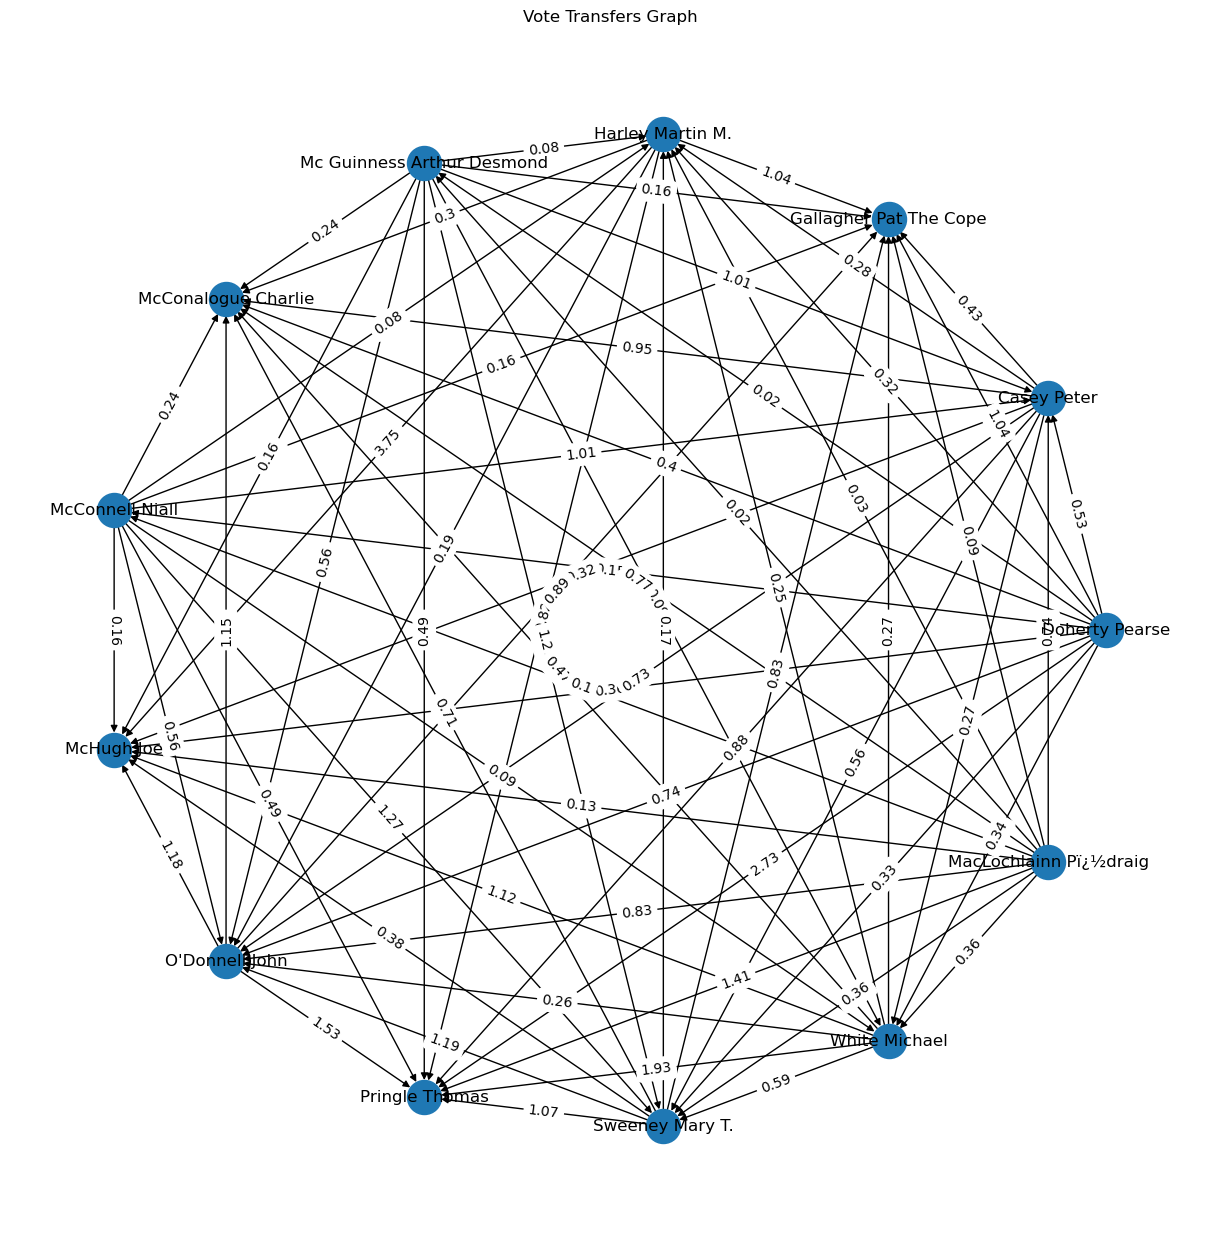

In [21]:
plot_G(G1)

In [10]:
def plot_G(G):
    #--Draw the graph
    plt.figure(figsize=(12, 12))
    #pos = nx.spring_layout(G, seed=42,k=1, iterations=100)
    #pos=nx.get_node_attributes(G,'pos')
    opts = {"with_labels":True,"node_size":600}
    nx.draw_circular(G,**opts)

    #nx.draw_networkx_labels(G, label_pos, font_size=10, font_color='black')
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos=nx.circular_layout(G), edge_labels=edge_labels)
    plt.title("Vote Transfers Graph")
    plt.savefig("filename1.png")
    plt.show()

In [4]:
donegal_df = pd.read_excel("C:/Users/22358313/Desktop/University/BSc Fourth Year/FYP/Election_Data_CSVs/general_election_2020_count_details.xlsx",
                           engine='openpyxl',
                           sheet_name = "donegal-normalised")

In [5]:
donegal_df

,Constituency Name,Candidate surname,Candidate First Name,Result,Count Number,Non-Transferable,Occurred On Count,Required To Reach Quota,Required To Save Deposit,Transfers,ln(Transfers),Votes,Total Votes,Constituency Number,Candidate Id
0,Donegal,Casey,Peter,NaN,1,0,0,11766,2085,0,0.000000,1143,1143,9,161
1,Donegal,Gallagher,Pat The Cope,NaN,1,0,0,5440,0,0,0.000000,7469,7469,9,163
2,Donegal,Harley,Martin M.,NaN,1,0,0,9853,172,0,0.000000,3056,3056,9,164
3,Donegal,Mc Guinness,Arthur Desmond,NaN,1,0,0,12853,3172,0,0.000000,56,56,9,168
4,Donegal,McConalogue,Charlie,NaN,1,0,0,4562,0,0,0.000000,8347,8347,9,166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,Donegal,Gallagher,Pat The Cope,Excluded,9,0,9,1835,0,928,2.968016,7469,11074,9,163
113,Donegal,McConalogue,Charlie,Elected,9,0,9,1477,0,1162,3.065580,8347,11432,9,166
114,Donegal,McHugh,Joe,Elected,9,0,9,805,0,1184,3.073718,7621,12104,9,169
115,Donegal,O'Donnell,John,Excluded,9,0,9,0,0,-7106,-7106.000000,4735,0,9,170


In [7]:
def graph_of_data(df):
    #--Merge these columns, will be labels of the nodes
    df["Name"] = df["Candidate surname"].astype("str") +" " + df["Candidate First Name"].astype("str")
    #--Create the DiGraph
    G = nx.DiGraph()
    count_lst = list(df["Count Number"].unique())
    count_lst.remove(1)
    #--Filter by count
    for count in count_lst:
        filtered_df1 = df[df["Count Number"]==count]
        #--get names of those whose votes are transferred
        src_cands = filtered_df1[filtered_df1["Transfers"]<0]
        #--get names of those who receive these transfers
        to_cands =filtered_df1[filtered_df1["Transfers"]>0]
        src_names = list(src_cands["Name"].values)
        to_names = list(to_cands["Name"].values)

        #--add edge weights as the proportion of the src_cand's transfers the to_cand received.       
        src_wgts = list(src_cands["Transfers"].values)
        to_wgts = list(to_cands["Transfers"].values)

        #--if there's more than one src_cand per count, the number of transfers a candidate receives will a proportion of the this total
        total = np.abs(np.sum(src_wgts))

        wgts = [round(wgt/total, 2) for wgt in to_wgts]
            
        #--Create a weighted edge between each source candidate and each target candidate
        for i in range(len(src_names)):
            for j in range(len(to_names)):
                G.add_edge(src_names[i],to_names[j],weight=wgts[j])
    return G

In [8]:
G2 = graph_of_data(donegal_df)

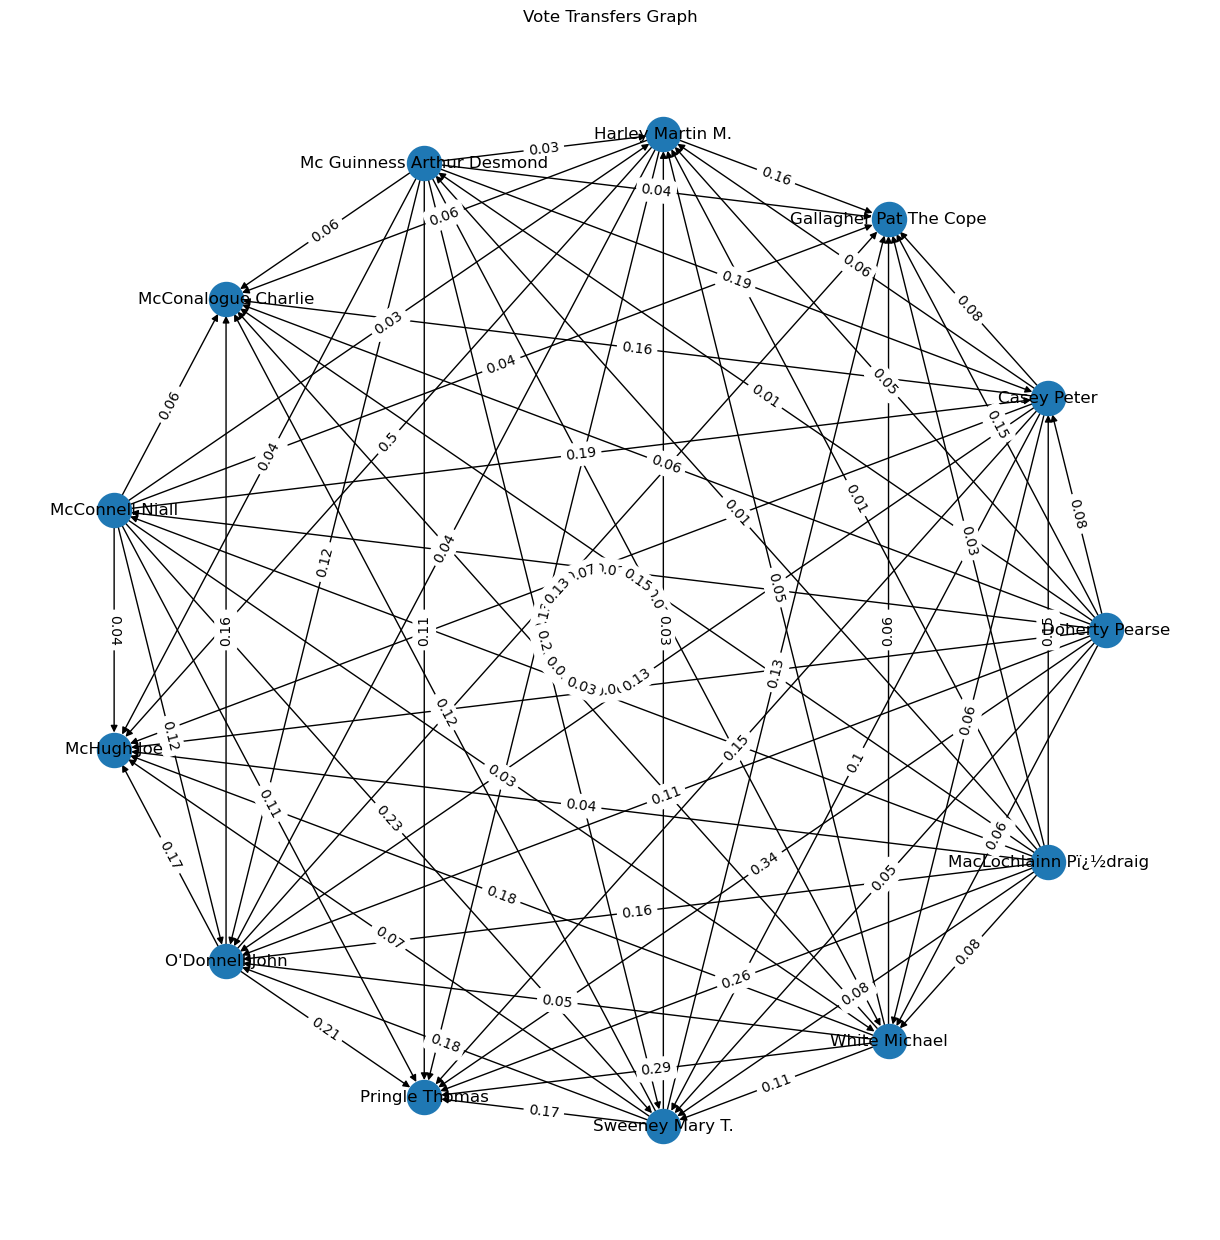

In [11]:
plot_G(G2)

In [9]:
for i in G2.edges("Mc Guinness Arthur Desmond",data=True):
    print(i)

('Mc Guinness Arthur Desmond', 'Casey Peter', {'weight': 0.19})
('Mc Guinness Arthur Desmond', 'Gallagher Pat The Cope', {'weight': 0.04})
('Mc Guinness Arthur Desmond', 'Harley Martin M.', {'weight': 0.03})
('Mc Guinness Arthur Desmond', 'McConalogue Charlie', {'weight': 0.06})
('Mc Guinness Arthur Desmond', 'McHugh Joe', {'weight': 0.04})
('Mc Guinness Arthur Desmond', "O'Donnell John", {'weight': 0.12})
('Mc Guinness Arthur Desmond', 'Pringle Thomas', {'weight': 0.11})
('Mc Guinness Arthur Desmond', 'Sweeney Mary T.', {'weight': 0.23})
('Mc Guinness Arthur Desmond', 'White Michael', {'weight': 0.03})


In [71]:
for i in G2.edges("Doherty Pearse",data=True):
    print(i)

('Doherty Pearse', 'Casey Peter', {'weight': 0.08})
('Doherty Pearse', 'Gallagher Pat The Cope', {'weight': 0.15})
('Doherty Pearse', 'Harley Martin M.', {'weight': 0.05})
('Doherty Pearse', 'Mc Guinness Arthur Desmond', {'weight': 0.01})
('Doherty Pearse', 'McConalogue Charlie', {'weight': 0.06})
('Doherty Pearse', 'McConnell Niall', {'weight': 0.03})
('Doherty Pearse', 'McHugh Joe', {'weight': 0.06})
('Doherty Pearse', "O'Donnell John", {'weight': 0.11})
('Doherty Pearse', 'Pringle Thomas', {'weight': 0.34})
('Doherty Pearse', 'Sweeney Mary T.', {'weight': 0.05})
('Doherty Pearse', 'White Michael', {'weight': 0.06})


In [ ]:
communities = nx.community.louvain_communities(G2)